# Análise Exploratória de Dados: Doenças Cardíacas (UCI Heart Disease)

Este notebook apresenta uma análise exploratória detalhada da base de dados de doenças cardíacas da UCI. 
O objetivo é investigar a qualidade dos dados, identificar valores ausentes (incluindo os disfarçados) e visualizar padrões importantes.

### Estrutura dos Dados:
- **age**: Idade em anos
- **sex**: Sexo (Male/Female)
- **dataset**: Local da coleta
- **cp**: Tipo de dor no peito
- **trestbps**: Pressão arterial em repouso
- **chol**: Colesterol sérico em mg/dl
- **fbs**: Açúcar no sangue em jejum > 120 mg/dl
- **restecg**: Resultados eletrocardiográficos em repouso
- **thalch**: Frequência cardíaca máxima atingida
- **exang**: Angina induzida por exercício
- **oldpeak**: Depressão de ST induzida pelo exercício em relação ao repouso
- **slope**: A inclinação do segmento ST de pico do exercício
- **ca**: Número de vasos principais coloridos por fluoroscopia
- **thal**: Tipo de defeito (normal, fixed defect, reversable defect)
- **num**: Diagnóstico de doença cardíaca (valor alvo)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display
from scipy.stats import shapiro
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import normaltest
from IPython.display import display
from scipy.stats import spearmanr
from scipy.stats import kruskal
from sklearn.feature_selection import mutual_info_classif
import scikit_posthocs as sp
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

## Carregamento

In [22]:
df = pd.read_csv('data/heart_disease_uci.csv')
print(f"Formato do dataset: {df.shape}")
df.head()

Formato do dataset: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Separando variáveis categóricas de numéricas

In [23]:
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
target = 'num'

## Análise de Missings (Considerando explícitos e implícitos)

In [24]:
missing_summary = pd.DataFrame({
    'missing': df.isnull().sum(),
    'missing_%': df.isnull().mean()*100,
    'zeros': (df == 0).sum(),
    'zeros_%': (df == 0).mean()*100
})

missing_summary

,missing,missing_%,zeros,zeros_%
id,0,0.000000,0,0.000000
age,0,0.000000,0,0.000000
sex,0,0.000000,0,0.000000
dataset,0,0.000000,0,0.000000
cp,0,0.000000,0,0.000000
trestbps,59,6.413043,1,0.108696
chol,30,3.260870,172,18.695652
fbs,90,9.782609,692,75.217391
restecg,2,0.217391,0,0.000000
thalch,55,5.978261,0,0.000000


### tratamento inicial

In [25]:
df.loc[df['chol'] == 0, 'chol'] = pd.NA
df.loc[df['trestbps'] == 0, 'trestbps'] = pd.NA

### verificando distribuição entre as categóricas

In [26]:
for col in cat_cols:
    print(f'\n{col}')
    print(df[col].value_counts(dropna=False))


sex
sex
Male      726
Female    194
Name: count, dtype: int64

cp
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

fbs
fbs
False    692
True     138
NaN       90
Name: count, dtype: int64

restecg
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2
Name: count, dtype: int64

exang
exang
False    528
True     337
NaN       55
Name: count, dtype: int64

slope
slope
flat           345
NaN            309
upsloping      203
downsloping     63
Name: count, dtype: int64

thal
thal
NaN                  486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


### Visualizando distribuições das categorias numéricas

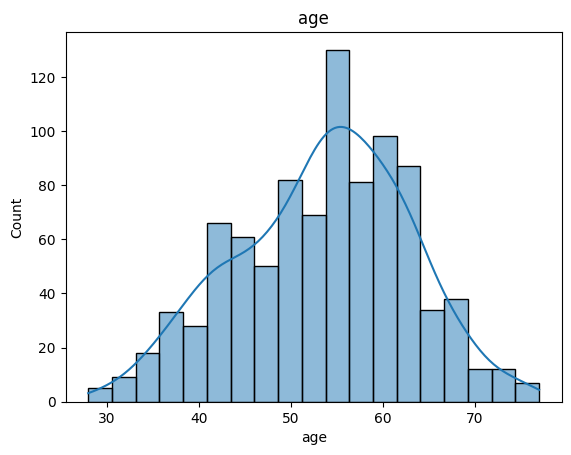

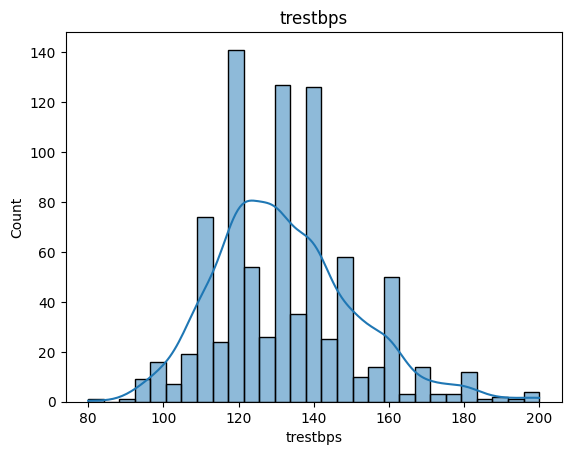

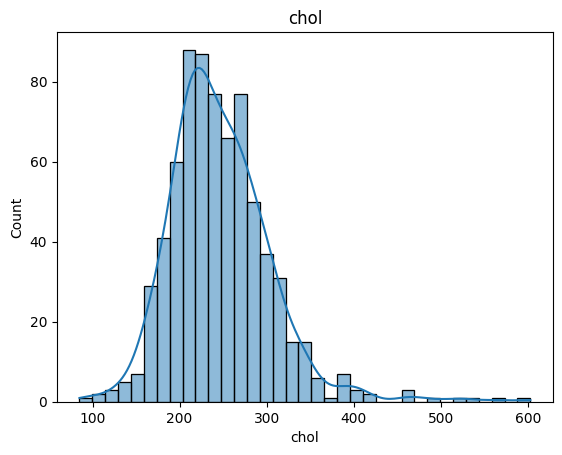

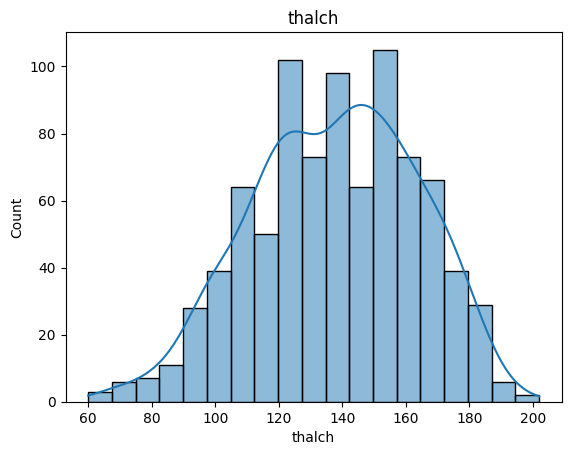

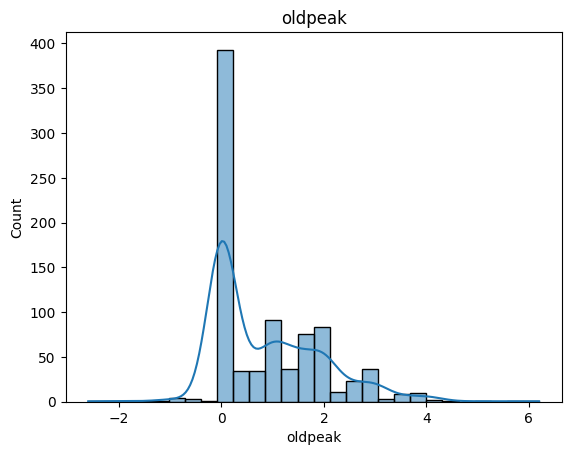

In [27]:
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

### Estatística descritiva

In [28]:
resumo = df[num_cols].describe().T
resumo['cv'] = resumo['std'] / resumo['mean']
resumo

,count,mean,std,min,25%,50%,75%,max,cv
age,920.0,53.510870,9.424685,28.0,47.0,54.0,60.00,77.0,0.176127
trestbps,860.0,132.286047,18.536175,80.0,120.0,130.0,140.00,200.0,0.140122
chol,718.0,246.832869,58.527062,85.0,210.0,239.5,276.75,603.0,0.237112
thalch,865.0,137.545665,25.926276,60.0,120.0,140.0,157.00,202.0,0.188492
oldpeak,858.0,0.878788,1.091226,-2.6,0.0,0.5,1.50,6.2,1.241740


### Normalidade

In [29]:
normalidade = []

for col in num_cols:
    dados = df[col].dropna()
    
    normalidade.append({
        'var': col,
        'shapiro_p': shapiro(dados)[1],
        'dagostino_p': normaltest(dados)[1],
        'skew': skew(dados),
        'kurtosis': kurtosis(dados)
    })

pd.DataFrame(normalidade)

,var,shapiro_p,dagostino_p,skew,kurtosis
0,age,2.267545e-05,8.083108e-04,-0.195674,-0.387367
1,trestbps,1.409244e-12,2.182876e-13,0.629059,0.619949
2,chol,7.791516e-18,9.444884e-47,1.312118,4.731338
3,thalch,1.905662e-05,3.273949e-05,-0.210752,-0.483885
4,oldpeak,8.813866e-28,3.178200e-29,1.039605,1.113527


### Distribuição Target

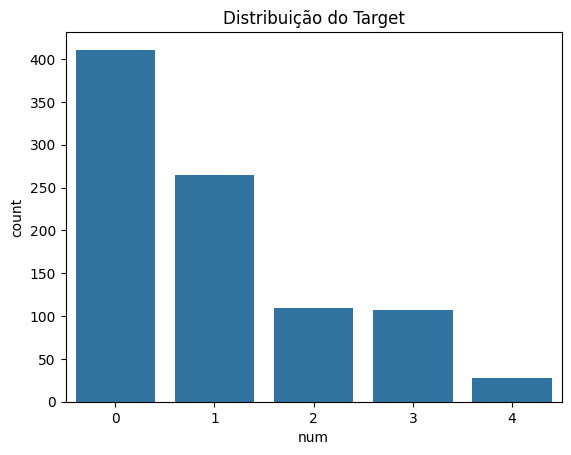

In [30]:
sns.countplot(data=df, x='num')
plt.title('Distribuição do Target')
plt.show()

### Correlação entre numéricas

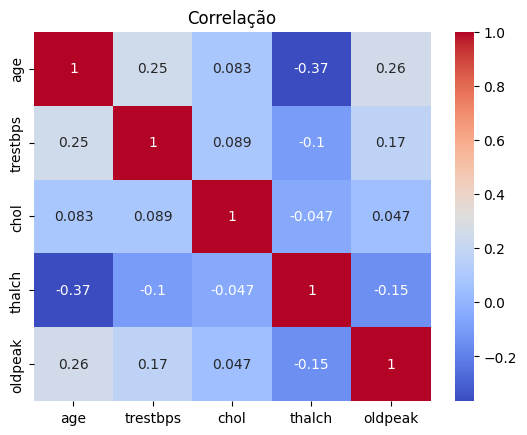

In [31]:
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlação')
plt.show()

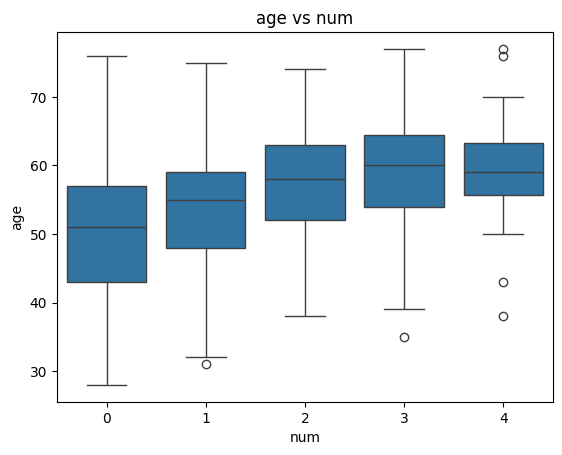

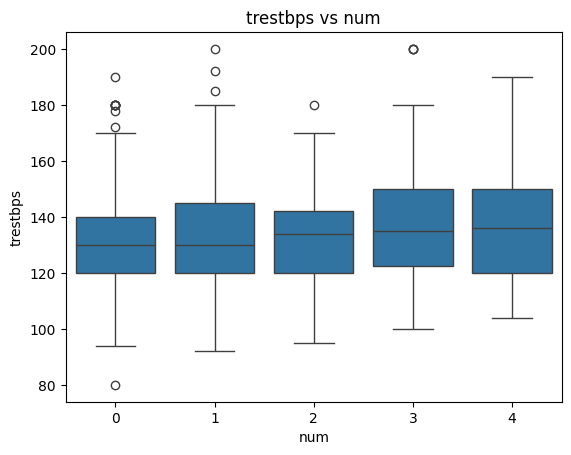

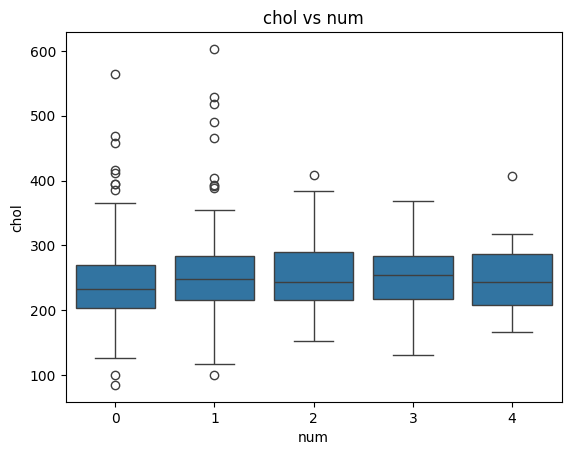

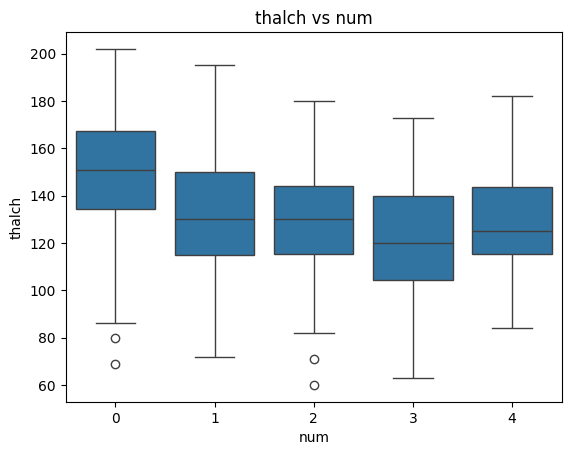

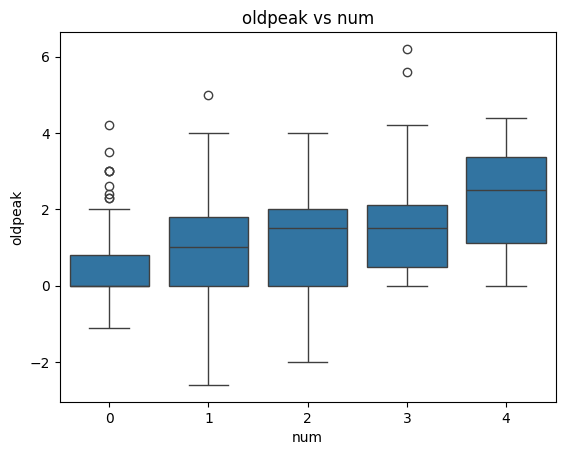

In [32]:
for col in num_cols:
    sns.boxplot(data=df, x='num', y=col)
    plt.title(f'{col} vs num')
    plt.show()

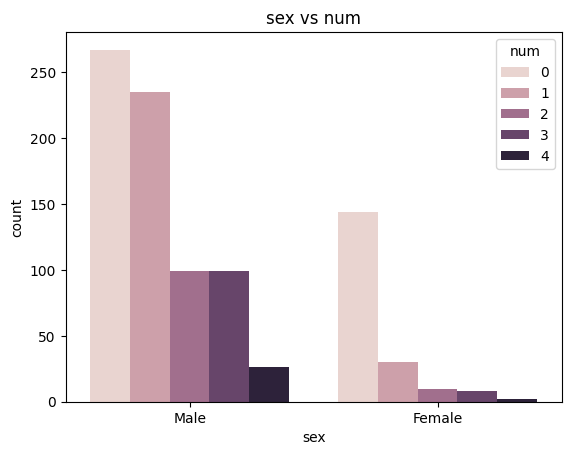

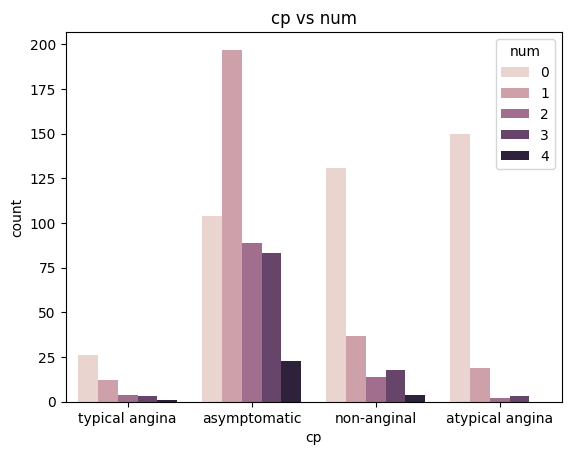

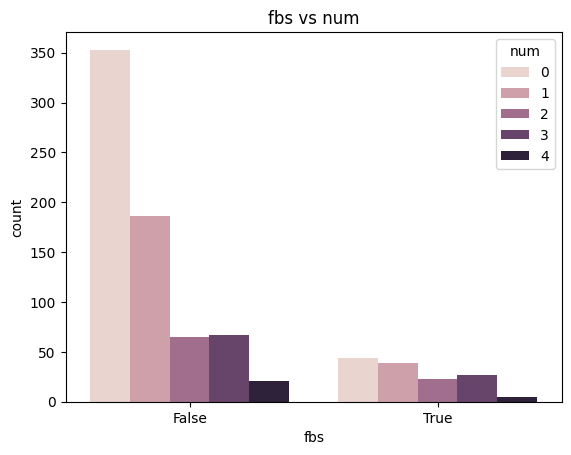

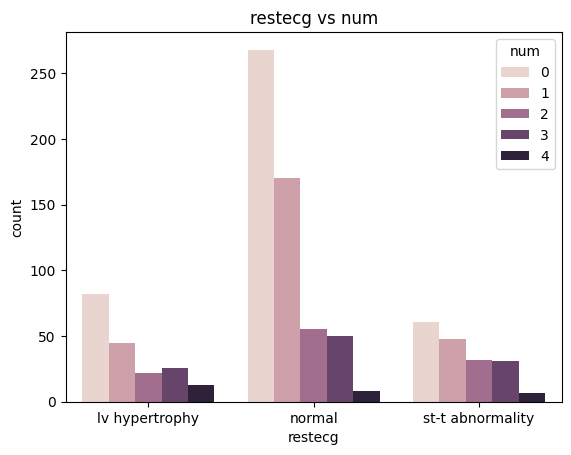

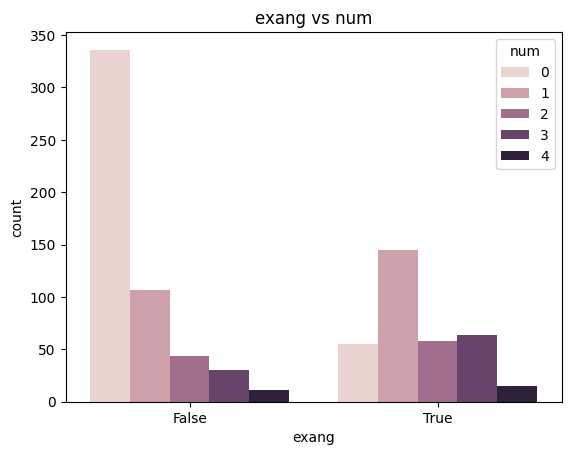

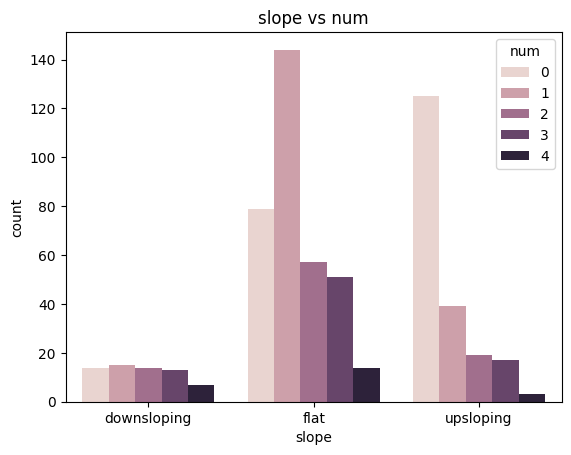

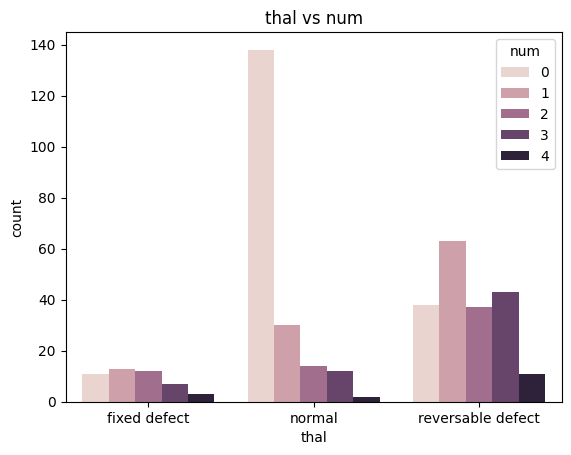

In [33]:
for col in cat_cols:
    sns.countplot(data=df, x=col, hue='num')
    plt.title(f'{col} vs num')
    plt.show()

### Correlaçãp Spearman com Target

In [34]:
for col in num_cols:
    corr, p = spearmanr(df[col], df['num'])
    print(col, round(corr,3), f"p={p:.2e}")

age 0.347 p=1.87e-27
trestbps nan p=nan
chol nan p=nan
thalch nan p=nan
oldpeak nan p=nan


### Teste de diferença (Kruskal-Wallis)

In [35]:
for col in num_cols:
    grupos = [df[df['num']==i][col].dropna() for i in sorted(df['num'].unique())]
    stat, p = kruskal(*grupos)
    print(col, f"p={p:.2e}")

age p=3.73e-24
trestbps p=4.08e-03
chol p=1.79e-02
thalch p=1.79e-30
oldpeak p=1.27e-34


### Pós-teste (Dunn) - opcional

In [36]:
sp.posthoc_dunn(df, val_col='age', group_col='num', p_adjust='bonferroni')

,0,1,2,3,4
0,1.000000e+00,3.590783e-04,5.939450e-12,6.028249e-17,0.000017
1,3.590783e-04,1.000000e+00,7.563711e-04,9.458146e-07,0.021607
2,5.939450e-12,7.563711e-04,1.000000e+00,1.000000e+00,1.000000
3,6.028249e-17,9.458146e-07,1.000000e+00,1.000000e+00,1.000000
4,1.689006e-05,2.160739e-02,1.000000e+00,1.000000e+00,1.000000


### Feature importance (visão de modelo)

In [37]:
X = df[num_cols + cat_cols]
y = df[target]

X = pd.get_dummies(X, drop_first=True)

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

thalch                      0.148756
chol                        0.147041
age                         0.139675
oldpeak                     0.116571
trestbps                    0.108225
exang_True                  0.054485
cp_atypical angina          0.039273
slope_flat                  0.036730
thal_reversable defect      0.030922
cp_non-anginal              0.029284
sex_Male                    0.026730
restecg_normal              0.026111
fbs_True                    0.024033
thal_normal                 0.023305
restecg_st-t abnormality    0.020514
slope_upsloping             0.017721
cp_typical angina           0.010624
dtype: float64

### Mutual Information

In [39]:
X = X.dropna()
y = y.loc[X.index]

mi = mutual_info_classif(X, y, random_state=42)
pd.Series(mi, index=X.columns).sort_values(ascending=False)

exang_True                  0.168040
oldpeak                     0.143073
slope_flat                  0.066381
thal_reversable defect      0.060639
age                         0.055358
cp_atypical angina          0.047448
sex_Male                    0.046497
thalch                      0.043062
thal_normal                 0.042412
slope_upsloping             0.036666
fbs_True                    0.035435
cp_non-anginal              0.020147
chol                        0.019178
trestbps                    0.005803
cp_typical angina           0.000000
restecg_st-t abnormality    0.000000
restecg_normal              0.000000
dtype: float64